In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import seaborn as sb
import pandas as pd
import tensorflow as tf
import cv2, json
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
from SabreNet import dice_loss_plus_bce, iou_metric, dice_coefficient
from utils import plot_history, data_gen
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3060 (UUID: GPU-81f6e2eb-490f-a94c-111c-389f658c4c02)


In [2]:
files = glob.glob('dataset/Segmentation/*/*')

In [3]:
lab = {'glioma' : 0, 'meningioma' : 1, 'pituitary' : 2}
rev_lab = dict(zip(lab.values(), lab.keys()))

In [4]:
image_path = [files[i] for i in range(0, len(files), 2)]
mask_path = [files[i] for i in range(1, len(files), 2)]

df = pd.DataFrame.from_dict({"image_path" : image_path, "mask_path" : mask_path})

df["label"] = df["image_path"].str.lower().str.split("\\").str[1]

df['label'] = df['label'].apply(lab.get)

df

,image_path,mask_path,label
0,dataset/Segmentation\Glioma\enh_1841.png,dataset/Segmentation\Glioma\enh_1841_mask.png,0
1,dataset/Segmentation\Glioma\enh_1842.png,dataset/Segmentation\Glioma\enh_1842_mask.png,0
2,dataset/Segmentation\Glioma\enh_1843.png,dataset/Segmentation\Glioma\enh_1843_mask.png,0
3,dataset/Segmentation\Glioma\enh_1844.png,dataset/Segmentation\Glioma\enh_1844_mask.png,0
4,dataset/Segmentation\Glioma\enh_1845.png,dataset/Segmentation\Glioma\enh_1845_mask.png,0
...,...,...,...
2187,dataset/Segmentation\Pituitary\enh_995.png,dataset/Segmentation\Pituitary\enh_995_mask.png,2
2188,dataset/Segmentation\Pituitary\enh_996.png,dataset/Segmentation\Pituitary\enh_996_mask.png,2
2189,dataset/Segmentation\Pituitary\enh_997.png,dataset/Segmentation\Pituitary\enh_997_mask.png,2
2190,dataset/Segmentation\Pituitary\enh_998.png,dataset/Segmentation\Pituitary\enh_998_mask.png,2


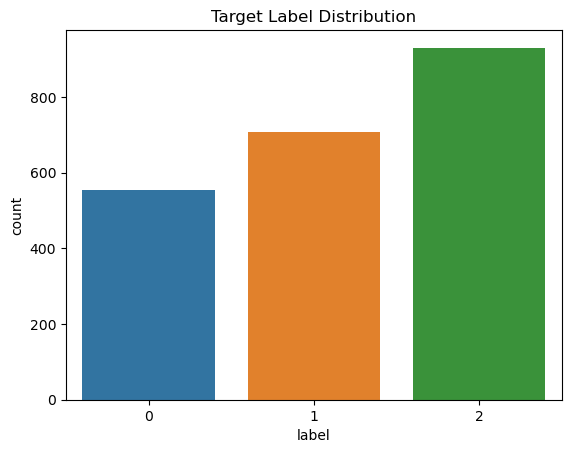

In [5]:
plt.title('Target Label Distribution')
sb.countplot(x = df['label'])
plt.show()

In [6]:
train_df, val_df  = train_test_split(df, test_size=0.20, random_state=100, stratify=df['label'])

In [7]:
len(train_df), len(val_df)

(1753, 439)

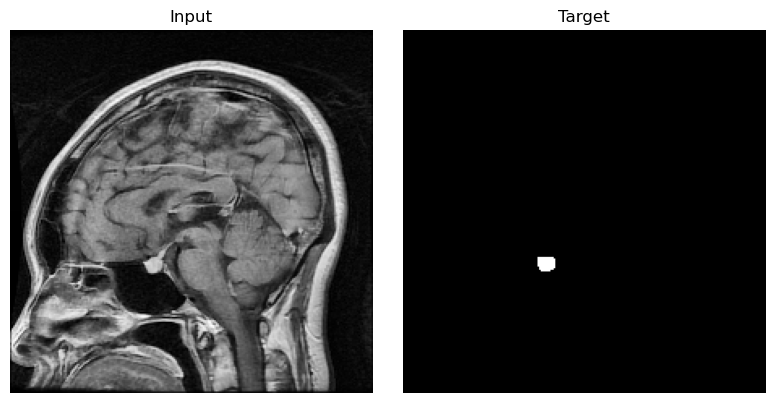

In [8]:
sampx, sampy = next(data_gen(val_df, 3))
sampy1, sampy2 = sampy

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].axis('off')
axes[0].imshow(sampx[1, ...], cmap='gray')
axes[0].set_title("Input")

axes[1].axis('off')
axes[1].imshow(sampy1[1, ...], cmap='gray')
axes[1].set_title("Target")

plt.tight_layout()
plt.show()

In [9]:
sampx.shape, sampy1.shape, sampy2.shape

((3, 224, 224, 1), (3, 224, 224, 1), (3, 3))

In [10]:
sampx.max(), sampy1.max()

(1.0, 1.0)

In [4]:
from UNet import build_unet

In [5]:
model = build_unet(input_shape=(224,224,1), num_classes=3)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = 0.0001),
    loss={'mask_pred': dice_loss_plus_bce,#bce_dice_loss,
          'classifier': 'categorical_crossentropy'
         },
    metrics={'mask_pred': [dice_coefficient, iou_metric],
             'classifier': ['accuracy']}
)

model.summary()

Model: "UNet_Baseline"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 224, 224, 1  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv (Conv2D)             (None, 112, 112, 64  3136        ['input[0][0]']                  
                                )                                                                 
                                                                                                  
 stem_bn (BatchNormalization)   (None, 112, 112, 64  256         ['stem_conv[0][0]']              
                                )                                                     

                                                                                                  
 dec1_conv2 (Conv2D)            (None, 14, 14, 256)  589824      ['dec1_relu1[0][0]']             
                                                                                                  
 dec1_bn2 (BatchNormalization)  (None, 14, 14, 256)  1024        ['dec1_conv2[0][0]']             
                                                                                                  
 dec1_relu2 (ReLU)              (None, 14, 14, 256)  0           ['dec1_bn2[0][0]']               
                                                                                                  
 up_sampling2d_1 (UpSampling2D)  (None, 28, 28, 256)  0          ['dec1_relu2[0][0]']             
                                                                                                  
 concatenate_1 (Concatenate)    (None, 28, 28, 384)  0           ['up_sampling2d_1[0][0]',        
          

In [13]:
tf.keras.utils.plot_model(model)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [14]:
batch_size = 4
train = data_gen(train_df, batch_size)
val = data_gen(train_df, batch_size)

In [15]:
calls = [
    ModelCheckpoint('BT_CLF_CNN.h5', monitor='mask_pred_loss', save_best_only=True, verbose=True, save_weights_only=True)
]

In [16]:
len(train_df)//batch_size, len(val_df)//batch_size

(438, 109)

In [17]:
history = model.fit(train, epochs = 1000, steps_per_epoch = 250, validation_data=val, validation_steps=50, callbacks = calls)

Epoch 1/1000
249/250 [============================>.] - ETA: 0s - loss: 1.7477 - mask_pred_loss: 0.9314 - classifier_loss: 0.8163 - mask_pred_dice_coefficient: 0.2338 - mask_pred_iou_metric: 0.1369 - classifier_accuracy: 0.6205
Epoch 1: mask_pred_loss improved from inf to 0.93123, saving model to BT_CLF_CNN.h5
250/250 [==============================] - 12s 33ms/step - loss: 1.7471 - mask_pred_loss: 0.9312 - classifier_loss: 0.8158 - mask_pred_dice_coefficient: 0.2337 - mask_pred_iou_metric: 0.1368 - classifier_accuracy: 0.6210 - val_loss: 2.5899 - val_mask_pred_loss: 1.1046 - val_classifier_loss: 1.4853 - val_mask_pred_dice_coefficient: 0.0373 - val_mask_pred_iou_metric: 0.0195 - val_classifier_accuracy: 0.4200
Epoch 2/1000
249/250 [============================>.] - ETA: 0s - loss: 1.4029 - mask_pred_loss: 0.7964 - classifier_loss: 0.6065 - mask_pred_dice_coefficient: 0.3537 - mask_pred_iou_metric: 0.2205 - classifier_accuracy: 0.7179
Epoch 2: mask_pred_loss improved from 0.93123 to 0.

250/250 [==============================] - 7s 30ms/step - loss: 0.8253 - mask_pred_loss: 0.6124 - classifier_loss: 0.2128 - mask_pred_dice_coefficient: 0.5127 - mask_pred_iou_metric: 0.3538 - classifier_accuracy: 0.9230 - val_loss: 0.8346 - val_mask_pred_loss: 0.6494 - val_classifier_loss: 0.1852 - val_mask_pred_dice_coefficient: 0.5048 - val_mask_pred_iou_metric: 0.3447 - val_classifier_accuracy: 0.9250
Epoch 13/1000
249/250 [============================>.] - ETA: 0s - loss: 0.8667 - mask_pred_loss: 0.6166 - classifier_loss: 0.2501 - mask_pred_dice_coefficient: 0.5153 - mask_pred_iou_metric: 0.3560 - classifier_accuracy: 0.9026
Epoch 13: mask_pred_loss did not improve from 0.61244
250/250 [==============================] - 7s 29ms/step - loss: 0.8658 - mask_pred_loss: 0.6166 - classifier_loss: 0.2492 - mask_pred_dice_coefficient: 0.5153 - mask_pred_iou_metric: 0.3560 - classifier_accuracy: 0.9030 - val_loss: 0.8672 - val_mask_pred_loss: 0.6563 - val_classifier_loss: 0.2109 - val_mask_

Epoch 24/1000
249/250 [============================>.] - ETA: 0s - loss: 0.6442 - mask_pred_loss: 0.5740 - classifier_loss: 0.0701 - mask_pred_dice_coefficient: 0.5485 - mask_pred_iou_metric: 0.3873 - classifier_accuracy: 0.9709
Epoch 24: mask_pred_loss improved from 0.57739 to 0.57473, saving model to BT_CLF_CNN.h5
250/250 [==============================] - 7s 30ms/step - loss: 0.6448 - mask_pred_loss: 0.5747 - classifier_loss: 0.0700 - mask_pred_dice_coefficient: 0.5481 - mask_pred_iou_metric: 0.3869 - classifier_accuracy: 0.9710 - val_loss: 0.7792 - val_mask_pred_loss: 0.5948 - val_classifier_loss: 0.1844 - val_mask_pred_dice_coefficient: 0.5324 - val_mask_pred_iou_metric: 0.3690 - val_classifier_accuracy: 0.9050
Epoch 25/1000
249/250 [============================>.] - ETA: 0s - loss: 0.6261 - mask_pred_loss: 0.5527 - classifier_loss: 0.0734 - mask_pred_dice_coefficient: 0.5638 - mask_pred_iou_metric: 0.4022 - classifier_accuracy: 0.9749
Epoch 25: mask_pred_loss improved from 0.5747

Epoch 36/1000
250/250 [==============================] - ETA: 0s - loss: 0.5793 - mask_pred_loss: 0.5434 - classifier_loss: 0.0359 - mask_pred_dice_coefficient: 0.5767 - mask_pred_iou_metric: 0.4146 - classifier_accuracy: 0.9860
Epoch 36: mask_pred_loss improved from 0.54934 to 0.54337, saving model to BT_CLF_CNN.h5
250/250 [==============================] - 7s 30ms/step - loss: 0.5793 - mask_pred_loss: 0.5434 - classifier_loss: 0.0359 - mask_pred_dice_coefficient: 0.5767 - mask_pred_iou_metric: 0.4146 - classifier_accuracy: 0.9860 - val_loss: 0.5803 - val_mask_pred_loss: 0.5752 - val_classifier_loss: 0.0051 - val_mask_pred_dice_coefficient: 0.5581 - val_mask_pred_iou_metric: 0.3971 - val_classifier_accuracy: 1.0000
Epoch 37/1000
250/250 [==============================] - ETA: 0s - loss: 0.6059 - mask_pred_loss: 0.5583 - classifier_loss: 0.0476 - mask_pred_dice_coefficient: 0.5643 - mask_pred_iou_metric: 0.4038 - classifier_accuracy: 0.9810
Epoch 37: mask_pred_loss did not improve from

Epoch 48/1000
250/250 [==============================] - ETA: 0s - loss: 0.5878 - mask_pred_loss: 0.5250 - classifier_loss: 0.0628 - mask_pred_dice_coefficient: 0.5914 - mask_pred_iou_metric: 0.4306 - classifier_accuracy: 0.9740
Epoch 48: mask_pred_loss improved from 0.53179 to 0.52504, saving model to BT_CLF_CNN.h5
250/250 [==============================] - 7s 30ms/step - loss: 0.5878 - mask_pred_loss: 0.5250 - classifier_loss: 0.0628 - mask_pred_dice_coefficient: 0.5914 - mask_pred_iou_metric: 0.4306 - classifier_accuracy: 0.9740 - val_loss: 2.4975 - val_mask_pred_loss: 0.5898 - val_classifier_loss: 1.9077 - val_mask_pred_dice_coefficient: 0.5374 - val_mask_pred_iou_metric: 0.3753 - val_classifier_accuracy: 0.6750
Epoch 49/1000
249/250 [============================>.] - ETA: 0s - loss: 0.5926 - mask_pred_loss: 0.5493 - classifier_loss: 0.0433 - mask_pred_dice_coefficient: 0.5722 - mask_pred_iou_metric: 0.4130 - classifier_accuracy: 0.9880
Epoch 49: mask_pred_loss did not improve from

...

Epoch 948/1000
249/250 [============================>.] - ETA: 0s - loss: 0.4432 - mask_pred_loss: 0.4432 - classifier_loss: 6.2238e-09 - mask_pred_dice_coefficient: 0.6589 - mask_pred_iou_metric: 0.4995 - classifier_accuracy: 1.0000
Epoch 948: mask_pred_loss did not improve from 0.41515
250/250 [==============================] - 7s 29ms/step - loss: 0.4438 - mask_pred_loss: 0.4438 - classifier_loss: 6.1989e-09 - mask_pred_dice_coefficient: 0.6585 - mask_pred_iou_metric: 0.4990 - classifier_accuracy: 1.0000 - val_loss: 0.4509 - val_mask_pred_loss: 0.4509 - val_classifier_loss: 1.1921e-09 - val_mask_pred_dice_coefficient: 0.6557 - val_mask_pred_iou_metric: 0.4969 - val_classifier_accuracy: 1.0000
Epoch 949/1000
249/250 [============================>.] - ETA: 0s - loss: 0.4436 - mask_pred_loss: 0.4436 - classifier_loss: 2.1492e-05 - mask_pred_dice_coefficient: 0.6591 - mask_pred_iou_metric: 0.4998 - classifier_accuracy: 1.0000
Epoch 949: mask_pred_loss did not improve from 0.41515
250/25

Epoch 960/1000
250/250 [==============================] - ETA: 0s - loss: 0.4343 - mask_pred_loss: 0.4343 - classifier_loss: 9.0844e-07 - mask_pred_dice_coefficient: 0.6694 - mask_pred_iou_metric: 0.5114 - classifier_accuracy: 1.0000
Epoch 960: mask_pred_loss did not improve from 0.41515
250/250 [==============================] - 7s 29ms/step - loss: 0.4343 - mask_pred_loss: 0.4343 - classifier_loss: 9.0844e-07 - mask_pred_dice_coefficient: 0.6694 - mask_pred_iou_metric: 0.5114 - classifier_accuracy: 1.0000 - val_loss: 0.4554 - val_mask_pred_loss: 0.4554 - val_classifier_loss: 2.6047e-07 - val_mask_pred_dice_coefficient: 0.6433 - val_mask_pred_iou_metric: 0.4799 - val_classifier_accuracy: 1.0000
Epoch 961/1000
250/250 [==============================] - ETA: 0s - loss: 0.4376 - mask_pred_loss: 0.4376 - classifier_loss: 1.2846e-05 - mask_pred_dice_coefficient: 0.6668 - mask_pred_iou_metric: 0.5088 - classifier_accuracy: 1.0000
Epoch 961: mask_pred_loss did not improve from 0.41515
250/25

Epoch 972/1000
250/250 [==============================] - ETA: 0s - loss: 0.4444 - mask_pred_loss: 0.4444 - classifier_loss: 1.5557e-05 - mask_pred_dice_coefficient: 0.6585 - mask_pred_iou_metric: 0.4995 - classifier_accuracy: 1.0000
Epoch 972: mask_pred_loss did not improve from 0.41515
250/250 [==============================] - 7s 29ms/step - loss: 0.4444 - mask_pred_loss: 0.4444 - classifier_loss: 1.5557e-05 - mask_pred_dice_coefficient: 0.6585 - mask_pred_iou_metric: 0.4995 - classifier_accuracy: 1.0000 - val_loss: 0.4664 - val_mask_pred_loss: 0.4664 - val_classifier_loss: 6.7949e-08 - val_mask_pred_dice_coefficient: 0.6327 - val_mask_pred_iou_metric: 0.4711 - val_classifier_accuracy: 1.0000
Epoch 973/1000
250/250 [==============================] - ETA: 0s - loss: 0.4356 - mask_pred_loss: 0.4356 - classifier_loss: 2.3738e-06 - mask_pred_dice_coefficient: 0.6652 - mask_pred_iou_metric: 0.5059 - classifier_accuracy: 1.0000
Epoch 973: mask_pred_loss did not improve from 0.41515
250/25

Epoch 984/1000
249/250 [============================>.] - ETA: 0s - loss: 0.4565 - mask_pred_loss: 0.4489 - classifier_loss: 0.0076 - mask_pred_dice_coefficient: 0.6548 - mask_pred_iou_metric: 0.4963 - classifier_accuracy: 0.9990
Epoch 984: mask_pred_loss did not improve from 0.41515
250/250 [==============================] - 7s 29ms/step - loss: 0.4559 - mask_pred_loss: 0.4483 - classifier_loss: 0.0076 - mask_pred_dice_coefficient: 0.6553 - mask_pred_iou_metric: 0.4968 - classifier_accuracy: 0.9990 - val_loss: 0.4658 - val_mask_pred_loss: 0.4658 - val_classifier_loss: 4.4604e-06 - val_mask_pred_dice_coefficient: 0.6450 - val_mask_pred_iou_metric: 0.4841 - val_classifier_accuracy: 1.0000
Epoch 985/1000
250/250 [==============================] - ETA: 0s - loss: 0.4564 - mask_pred_loss: 0.4533 - classifier_loss: 0.0031 - mask_pred_dice_coefficient: 0.6524 - mask_pred_iou_metric: 0.4918 - classifier_accuracy: 0.9990
Epoch 985: mask_pred_loss did not improve from 0.41515
250/250 [=========

Epoch 996/1000
250/250 [==============================] - ETA: 0s - loss: 0.4404 - mask_pred_loss: 0.4404 - classifier_loss: 3.2911e-05 - mask_pred_dice_coefficient: 0.6632 - mask_pred_iou_metric: 0.5043 - classifier_accuracy: 1.0000
Epoch 996: mask_pred_loss did not improve from 0.41515
250/250 [==============================] - 7s 29ms/step - loss: 0.4404 - mask_pred_loss: 0.4404 - classifier_loss: 3.2911e-05 - mask_pred_dice_coefficient: 0.6632 - mask_pred_iou_metric: 0.5043 - classifier_accuracy: 1.0000 - val_loss: 0.4623 - val_mask_pred_loss: 0.4623 - val_classifier_loss: 8.2850e-08 - val_mask_pred_dice_coefficient: 0.6418 - val_mask_pred_iou_metric: 0.4785 - val_classifier_accuracy: 1.0000
Epoch 997/1000
250/250 [==============================] - ETA: 0s - loss: 0.4421 - mask_pred_loss: 0.4362 - classifier_loss: 0.0058 - mask_pred_dice_coefficient: 0.6660 - mask_pred_iou_metric: 0.5079 - classifier_accuracy: 0.9960
Epoch 997: mask_pred_loss did not improve from 0.41515
250/250 [=

In [19]:
# with open("training_history_cnn.json", "w") as f:
#     json.dump(history.history, f)

In [21]:
with open("training_history_cnn.json", "r") as f:
    history = json.load(f)

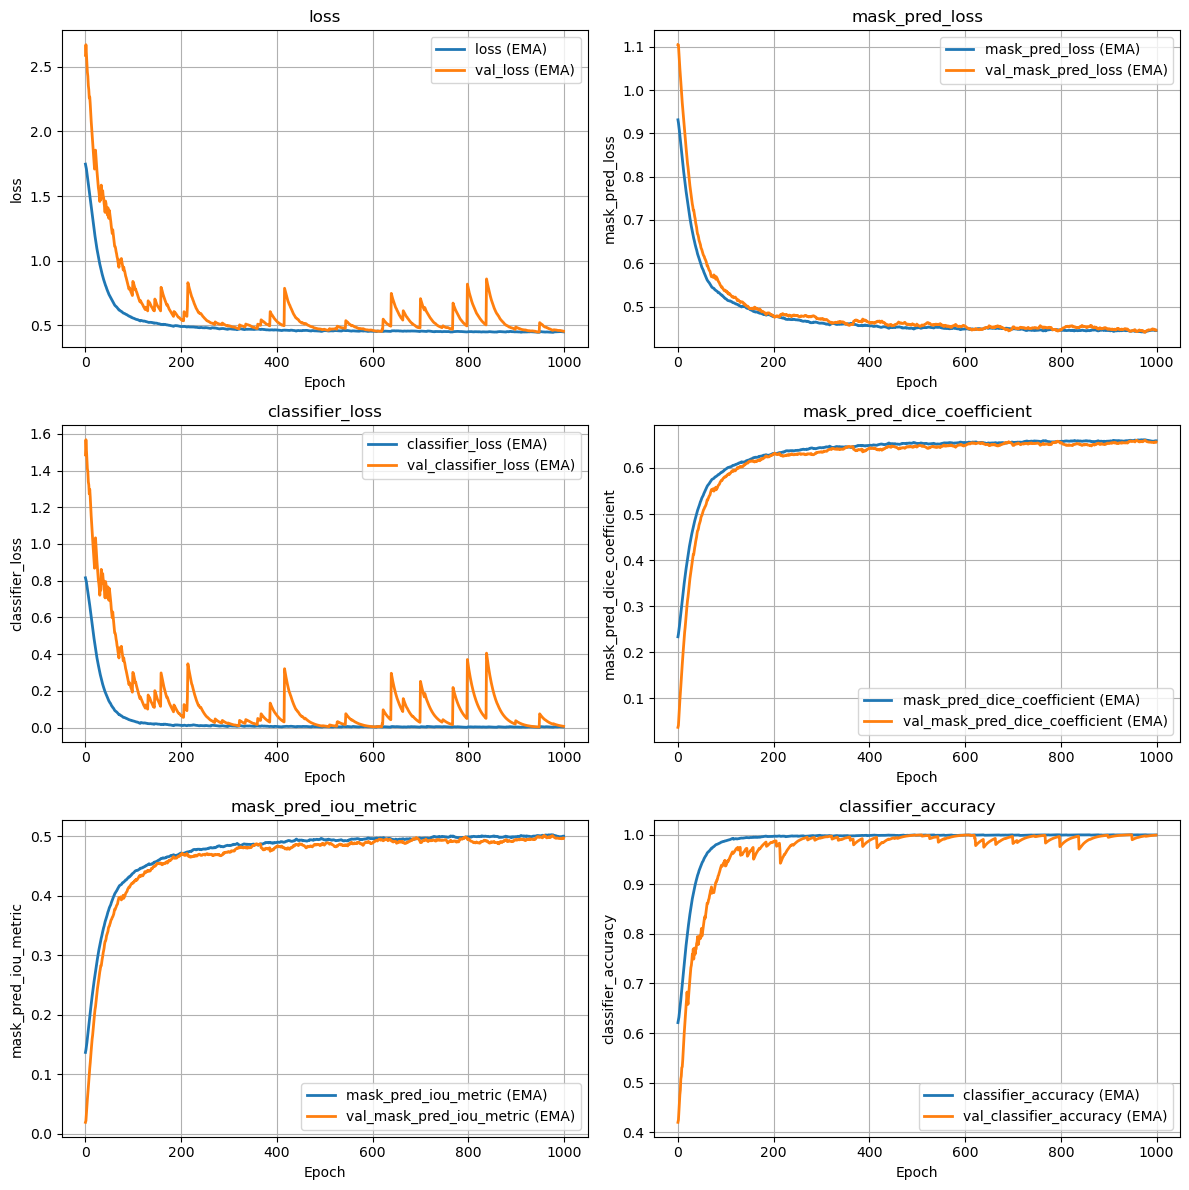

In [22]:
plot_history(history)

In [6]:
model.load_weights('BT_CLF_CNN.h5')

In [7]:
sampx, sampy1 = next(data_gen(val_df, 3))
sampy1, sampy2 = sampy1

NameError: name 'val_df' is not defined

In [ ]:
idx = 2

img = sampx[idx]

gt_cls = rev_lab.get(np.argmax(sampy2[idx]))
gt_mask = sampy1[idx]

print("GT: ", gt_cls)

res = model.predict(np.expand_dims(img, 0), verbose=False)
print(f"Pred: {rev_lab.get(np.argmax(res[1]))} ({np.max(res[1])})")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(res[0][0])
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
from grad_cam_cnn import plot_gradcam

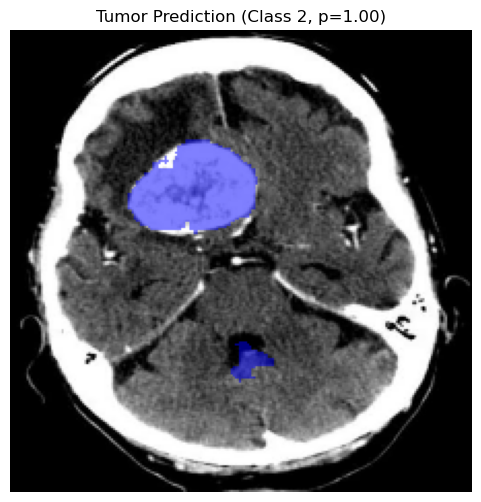

✅ Saved Predicted Mask Overlay
🔍 Grad-CAM → stem_conv


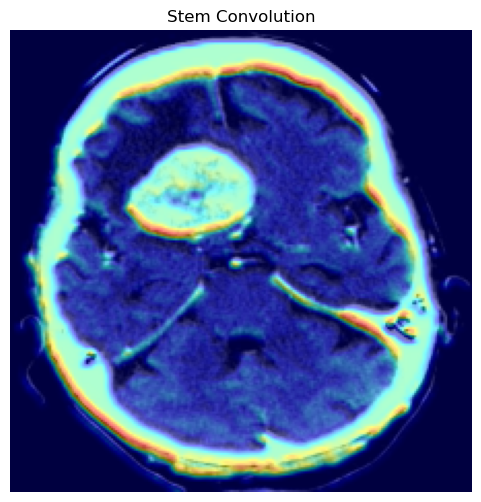

✅ Saved Report/Stem Convolution.png
🔍 Grad-CAM → enc1_conv2


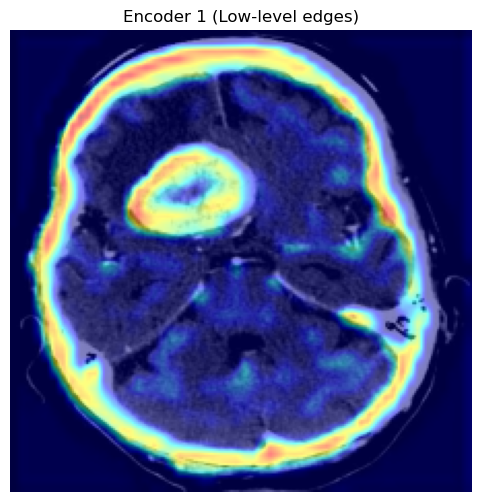

✅ Saved Report/Encoder 1 (Low-level edges).png
🔍 Grad-CAM → enc2_conv2


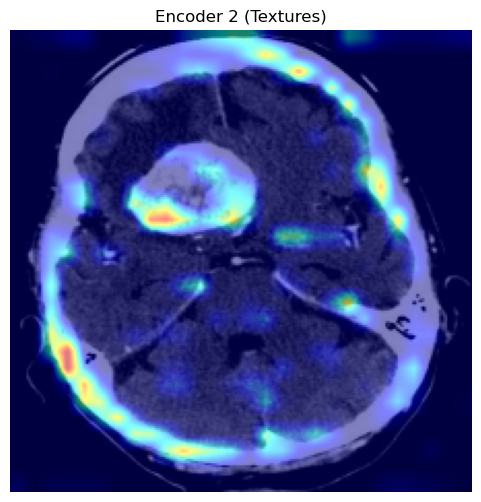

✅ Saved Report/Encoder 2 (Textures).png
🔍 Grad-CAM → enc3_conv2


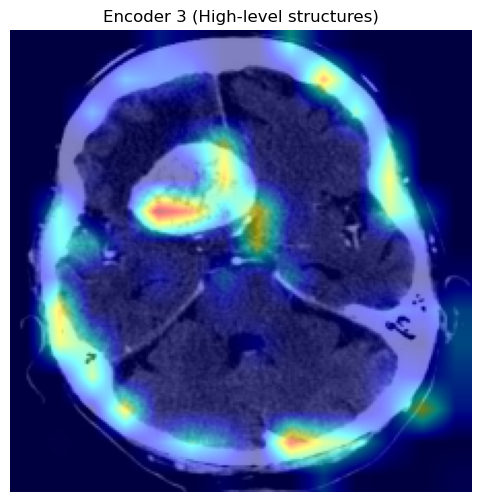

✅ Saved Report/Encoder 3 (High-level structures).png
🔍 Grad-CAM → bridge_conv2


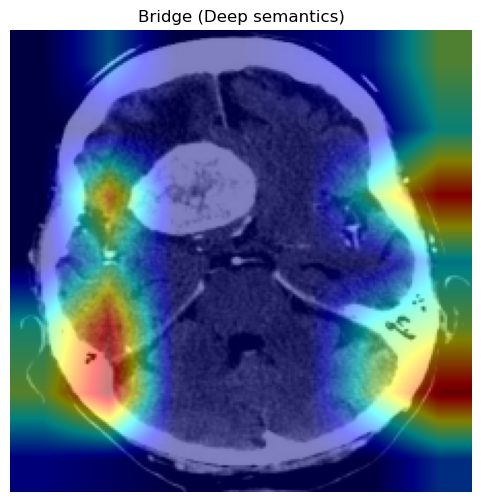

✅ Saved Report/Bridge (Deep semantics).png
🔍 Grad-CAM → dec1_conv2


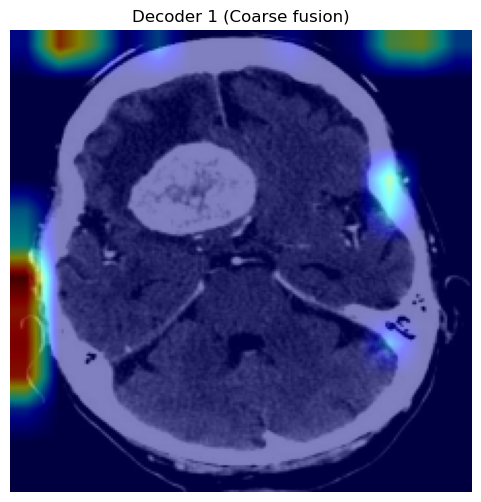

✅ Saved Report/Decoder 1 (Coarse fusion).png
🔍 Grad-CAM → dec2_conv2


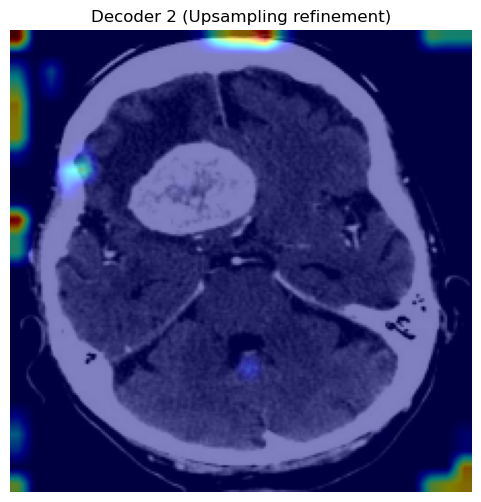

✅ Saved Report/Decoder 2 (Upsampling refinement).png
🔍 Grad-CAM → dec3_conv2


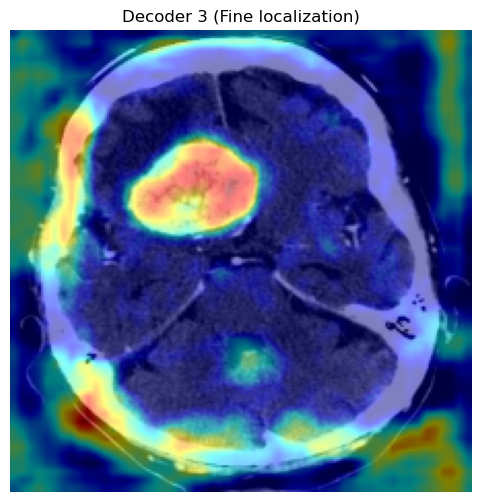

✅ Saved Report/Decoder 3 (Fine localization).png
🔍 Grad-CAM → mask_refine


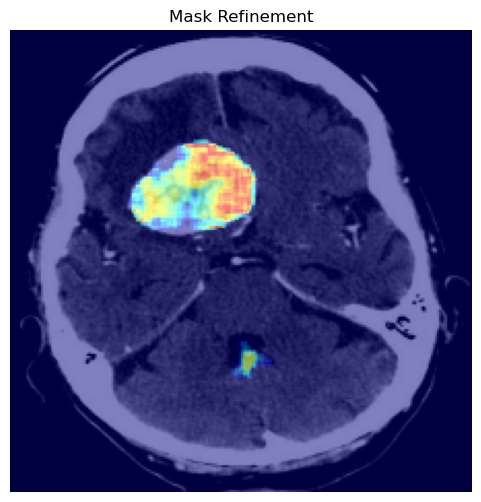

✅ Saved Report/Mask Refinement.png
🔍 Grad-CAM → mask_pred


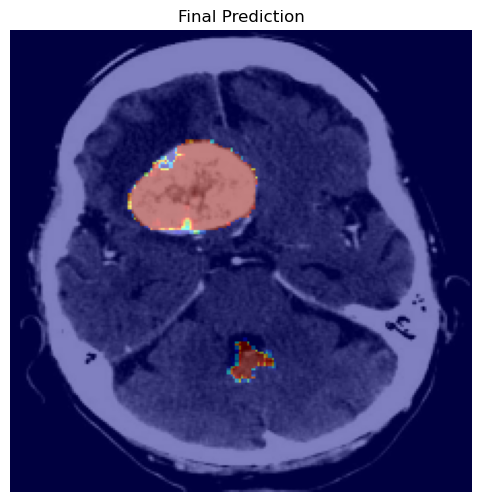

✅ Saved Report/Final Prediction.png


In [10]:
path = r"C:/Users/Lucifer/Downloads/Te-me_0015.jpg"
img = cv2.imread(path)
img = cv2.resize(img, [224,224])
plot_gradcam(img, model)